# Sieć neuronowa

#### Import bibliotek

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, accuracy_score

#### Funkcje do oceny skuteczności

In [3]:
def calculate_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    return accuracy, sensitivity, specificity

def plot_roc_curve(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Losowa klasyfikacja')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Krzywa ROC')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

def plot_confusion_matrix(y_true, y_pred, labels=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Macierz Pomyłek")
    plt.show()

def plot_dataset(X, y, title="Dataset"):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()
    
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                             np.arange(y_min, y_max, 0.01))
        
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
        
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap='viridis', s=50)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()


### Własna implementacja warstwy

In [4]:
class Layer:
    def __init__(self, n_inputs, n_outputs, activation='relu'):
        self.w = np.random.randn(n_inputs, n_outputs)
        self.b = np.random.rand(1, n_outputs)
        self.activation = activation

    def activate(self, x):
        self.z = x @ self.w + self.b
        if self.activation == 'relu':
            self.a =  np.maximum(0, x)
        elif self.activation == 'sigmoid':
            self.a =  1 / (1 + np.exp(-x))
        return self.a

    def activation_derivative(self, x):
        if self.activation == 'relu':
            return (x > 0).astype(float)
        elif self.activation == 'sigmoid':
            sig = 1 / (1 + np.exp(-self.z))
            return sig * (1 - sig)


### Własna implementcja sieci

In [5]:
class NeuralNet:
    def __init__(self, layers_dims, lr=0.01, epochs=1000, activation='relu'):
        self.layers_activation = activation
        self.lr = lr
        self.epochs = epochs
        self.layers = []

        for i in range(len(layers_dims)-2):
            self.layers.append(Layer(layers_dims[i], layers_dims[i+1], activation=self.layers_activation))
        self.layers.append(Layer(layers_dims[-2], layers_dims[-1], activation=self.layers_activation))

    def _forward(self, X):
        a = X
        for layer in self.layers:
            a = layer.activate(a)
        return a

    def _backward(self, X, y_true):
        m = y_true.shape[0]
        y_pred = self.layers[-1].a
        delta = y_pred - y_true 

        for i in reversed(range(len(self.layers))):
            a_prev = X if i == 0 else self.layers[i-1].a
            dw = (a_prev.T @ delta) / m
            db = np.sum(delta, axis=0, keepdims=True) / m

            self.layers[i].w -= self.lr * dw
            self.layers[i].b -= self.lr * db

            if i != 0:
                delta = (delta @ self.layers[i].w.T) * self.layers[i-1].activation_derivative()

    def train(self, X, y):
        for epoch in range(self.epochs):
            y_pred = self._forward(X)
            self._backward(X, y)
            if epoch % 100 == 0:
                loss = -np.sum(y * np.log(y_pred + 1e-8)) / y.shape[0]
                print(f"Epoch {epoch}, loss = {loss:.4f}")

    def predict(self, X):
        return np.argmax(self._forward(X), axis=1)

#### Genrowanie danych

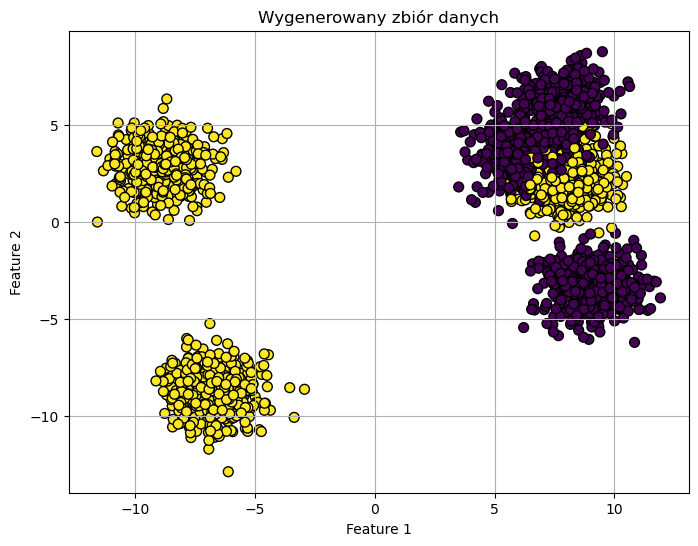

In [6]:
my_index = 259199
my_n_samples = int(str(my_index)[0]+ str(my_index)[1] + str(my_index)[-2] + str(my_index)[-1])

n_features = 2    
n_classes = 2     
n_clusters_per_class = 3

X_blobs, y_blobs = make_blobs(
    n_samples=my_n_samples,
    centers=n_classes * n_clusters_per_class,
    n_features=n_features,
    random_state=my_index
)

y_blobs = y_blobs % n_classes

plot_dataset(X_blobs, y_blobs, title="Wygenerowany zbiór danych")

#### Podział danych na treningowe i testowe

In [7]:
X_blobs_train, X_blobs_test, y_blobs_train, y_blobs_test = train_test_split(
    X_blobs, y_blobs, test_size=0.2, random_state=my_index
)

print("blobs:", X_blobs_train.shape, y_blobs_train.shape, X_blobs_test.shape, y_blobs_test.shape)

blobs: (2079, 2) (2079,) (520, 2) (520,)


### Trening na 5 warstwach

Relu

In [11]:
net = NeuralNet(layers_dims=[2, 10, 10, 10, 2], lr=0.05, epochs=1000, activation='relu')
net.train(X_blobs_train, y_blobs_train)

y_pred = net.predict(X_blobs_test)
y_true = np.argmax(y_blobs_test, axis=1)
acc = accuracy_score(y_true, y_pred)

accuracy, sensitivity, specificity = calculate_metrics(y_true, y_pred)
print(f"Dokładność: {acc:.4f}, Czułość: {sensitivity:.4f}, Specyficzność: {specificity:.4f}")
plot_decision_boundary(net, X_blobs_test, y_blobs_test, title="Granica decyzyjna")
plot_confusion_matrix(y_true, y_pred, labels=["Klasa 0", "Klasa 1"])
plot_roc_curve(y_true, y_pred)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 10 is different from 2)

Sigmoid

In [ ]:
net = NeuralNet(layers_dims=[2, 10, 10, 10, 2], lr=0.05, epochs=1000, activation='sigmoid')
net.train(X_blobs_train, y_blobs_train)

y_pred = net.predict(X_blobs_test)
y_true = np.argmax(y_blobs_test, axis=1)
acc = accuracy_score(y_true, y_pred)

accuracy, sensitivity, specificity = calculate_metrics(y_true, y_pred)
print(f"Dokładność: {acc:.4f}, Czułość: {sensitivity:.4f}, Specyficzność: {specificity:.4f}")
plot_decision_boundary(net, X_blobs_test, y_blobs_test, title="Granica decyzyjna")
plot_confusion_matrix(y_true, y_pred, labels=["Klasa 0", "Klasa 1"])
plot_roc_curve(y_true, y_pred)